# Assignment 8: Streamflow prediction from rainfall with neural networks

Predicting how much water will be in a river in a few days' time is the core of flood
forecasting, reservoir operation and drought management. The physical problem is
**rainfall-runoff**: rain falls on a catchment, some evaporates, some soaks into the soil,
some runs off into the channel, and the river responds hours to days later. That response is
strongly **nonlinear** (the same 20 mm of rain produces a trickle on dry ground in August and a flood on saturated ground in March) and it depends on the *history* of the catchment,
not just today's weather.

That combination makes it a natural neural network problem, and it is one of the areas where
machine learning has most clearly outperformed traditional conceptual hydrological models.

You will use two real public datasets:

- **USGS streamflow**: daily mean discharge measured at gauging stations, the backbone of
  US water resource monitoring.
- **Daymet**: daily gridded precipitation and temperature for North America, from Oak Ridge
  National Laboratory.

Both are free and need no API key. You will build a **regional** model: one network trained
on six catchments at once, rather than a separate model per river.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 8. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


In [1]:
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load the data

Six gauged catchments, chosen to be small enough that a single Daymet grid cell is a
reasonable summary of the rain falling on them, and to span a range of climates from
northern Maine to the southern Appalachians. `drainage_sq_mi` is the catchment area.

This downloads twelve time series and takes a couple of minutes.

In [2]:
BASINS = {
    # site_no: (latitude, longitude, drainage area in square miles, name)
    "02177000": (34.8138, -83.3064,  207, "Chattooga River, GA"),
    "01547700": (41.0595, -77.6058, 44.1, "Marsh Creek, PA"),
    "01013500": (47.2375, -68.5828,  870, "Fish River, ME"),
    "01543500": (41.3173, -78.1031,  685, "Sinnemahoning Creek, PA"),
    "02143040": (35.6640, -81.2140, 62.0, "Henry Fork, NC"),
    "03164000": (36.6473, -80.9790, 1141, "New River, VA"),
}
START, END = "1995-01-01", "2020-12-31"


def load_basin(site, lat, lon, area, name):
    """Daily discharge from USGS plus daily weather from Daymet, joined on date."""
    # USGS daily values, parameter 00060 = discharge in cubic feet per second.
    url = (f"https://waterservices.usgs.gov/nwis/dv/?format=rdb&sites={site}"
           f"&startDT={START}&endDT={END}&parameterCd=00060&siteStatus=all")
    text = urllib.request.urlopen(url).read().decode()
    rows = [line.split("\t") for line in text.splitlines() if line.startswith("USGS")]
    flow = pd.DataFrame(rows).iloc[:, [2, 3]]
    flow.columns = ["date", "discharge_cfs"]
    flow["date"] = pd.to_datetime(flow["date"])
    flow["discharge_cfs"] = pd.to_numeric(flow["discharge_cfs"], errors="coerce")

    # Daymet single-pixel extraction at the gauge location.
    url = (f"https://daymet.ornl.gov/single-pixel/api/data?lat={lat}&lon={lon}"
           f"&vars=prcp,tmax,tmin&start={START}&end={END}")
    met = pd.read_csv(io.StringIO(urllib.request.urlopen(url).read().decode()), skiprows=6)
    met.columns = ["year", "yday", "prcp", "tmax", "tmin"]
    met["date"] = (pd.to_datetime(met["year"].astype(str), format="%Y")
                   + pd.to_timedelta(met["yday"] - 1, unit="D"))

    df = met.merge(flow, on="date", how="inner").sort_values("date").reset_index(drop=True)
    df["site"] = site
    df["name"] = name
    df["area_sq_mi"] = area
    df["lat"] = lat
    df["lon"] = lon
    return df


frames = []
for site, (lat, lon, area, name) in BASINS.items():
    d = load_basin(site, lat, lon, area, name)
    print(f"{name:<26} {len(d):>6,} days  "
          f"{d.date.min().date()} to {d.date.max().date()}")
    frames.append(d)

raw = pd.concat(frames, ignore_index=True)
print(f"\ntotal: {len(raw):,} basin-days across {raw.site.nunique()} catchments")
raw.head()

Chattooga River, GA         9,490 days  1995-01-01 to 2020-12-30


Marsh Creek, PA             9,490 days  1995-01-01 to 2020-12-30


Fish River, ME              9,490 days  1995-01-01 to 2020-12-30


Sinnemahoning Creek, PA     9,490 days  1995-01-01 to 2020-12-30


Henry Fork, NC              9,490 days  1995-01-01 to 2020-12-30


New River, VA               9,490 days  1995-01-01 to 2020-12-30

total: 56,940 basin-days across 6 catchments


,year,yday,prcp,tmax,tmin,date,discharge_cfs,site,name,area_sq_mi,lat,lon
0,1995,1,0.0,13.42,3.80,1995-01-01,643.0,02177000,"Chattooga River, GA",207.0,34.8138,-83.3064
1,1995,2,0.0,9.22,-2.67,1995-01-02,588.0,02177000,"Chattooga River, GA",207.0,34.8138,-83.3064
2,1995,3,0.0,7.03,-4.34,1995-01-03,564.0,02177000,"Chattooga River, GA",207.0,34.8138,-83.3064
3,1995,4,0.0,5.93,-5.19,1995-01-04,557.0,02177000,"Chattooga River, GA",207.0,34.8138,-83.3064
4,1995,5,0.0,4.55,-10.18,1995-01-05,540.0,02177000,"Chattooga River, GA",207.0,34.8138,-83.3064


```{admonition} Note on Daymet's calendar
:class: note
Daymet uses a 365-day year and omits 31 December in leap years, so the inner join above
silently drops those days. That is fine here, but it is the kind of thing worth noticing
when you join two climate datasets: a silent loss of six days per two decades is easy to
miss and not always harmless.
```

## Part 1: Explore the data

1. Plot the discharge time series for one catchment over a five-year window, with a
logarithmic y-axis. Describe the shape of the hydrograph, what do the rises look like
compared with the falls, and why are they asymmetric?

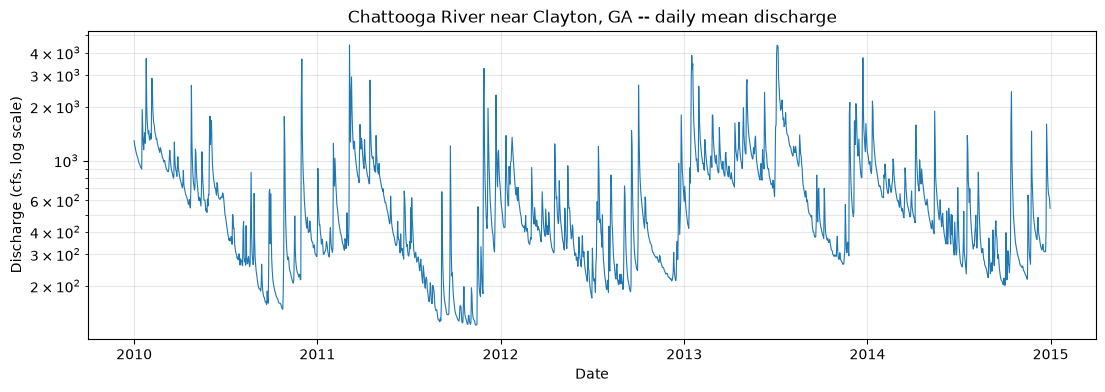

In [3]:
one = raw[raw.site == "02177000"]
win = one[(one.date >= "2010-01-01") & (one.date < "2015-01-01")]

fig, ax = plt.subplots(figsize=(13, 4))
ax.semilogy(win.date, win.discharge_cfs, lw=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (cfs, log scale)")
ax.set_title("Chattooga River near Clayton, GA -- daily mean discharge")
ax.grid(alpha=0.3, which="both")
plt.show()

# The hydrograph is strongly ASYMMETRIC: sharp, near-vertical rises followed by long,
# smooth, concave recessions. A storm delivers water to the channel over hours, so the
# rising limb is as fast as the rain. Afterwards the channel is fed by water draining slowly
# out of soil and groundwater storage, which empties at a rate proportional to how much is
# left -- an exponential decay, which is why the recession looks straight on a log axis.
#
# That exponential recession is the reason a log transform is the right move in question 2,
# and it is also why the previous few days of flow are such powerful predictors: between
# storms, tomorrow's flow is almost a deterministic function of today's.

2. Plot the distribution of daily discharge for all catchments together, first on a linear
scale and then after a $\log(1+x)$ transform. Which is easier to model with a squared-error
loss, and why does streamflow have this shape?

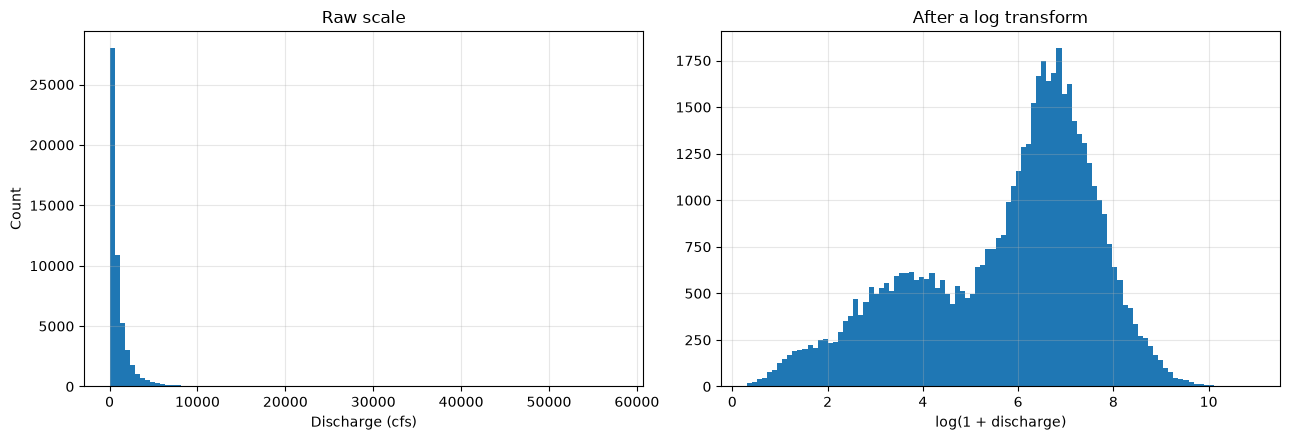

raw:   median    517.0  mean    991.1  99th pct    7510.0  max   57800.0
log:   median     6.25  mean     5.74  99th pct      8.92  max     10.96


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(raw.discharge_cfs.dropna(), bins=100)
axes[0].set_xlabel("Discharge (cfs)"); axes[0].set_ylabel("Count")
axes[0].set_title("Raw scale"); axes[0].grid(alpha=0.3)

axes[1].hist(np.log1p(raw.discharge_cfs.dropna()), bins=100)
axes[1].set_xlabel("log(1 + discharge)")
axes[1].set_title("After a log transform"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

q = raw.discharge_cfs.dropna()
print(f"raw:   median {q.median():8.1f}  mean {q.mean():8.1f}  "
      f"99th pct {q.quantile(0.99):9.1f}  max {q.max():9.1f}")
lq = np.log1p(q)
print(f"log:   median {lq.median():8.2f}  mean {lq.mean():8.2f}  "
      f"99th pct {lq.quantile(0.99):9.2f}  max {lq.max():9.2f}")

# The raw distribution is extremely right-skewed -- most days sit near the low-flow baseline
# and a handful of flood days are orders of magnitude larger. The log transform makes it
# roughly symmetric.
#
# The LOG VERSION is far easier to model with a squared-error loss, and the reason is
# specific to that loss. MSE penalizes the squared deviation, so on the raw scale a single
# flood day with an error of 5,000 cfs contributes as much to the loss as a million ordinary
# days with an error of 5 cfs. Training would be dominated by a few extreme days and the
# model would essentially ignore the rest of the record. On the log scale an error is
# effectively a RATIO error -- being wrong by a factor of two costs the same whether the flow
# is 50 cfs or 5,000 -- which is both numerically better behaved and closer to how a
# hydrologist thinks about forecast skill.
#
# Streamflow has this shape because runoff generation is threshold-like and multiplicative:
# most rain on unsaturated ground produces almost none, while rain on saturated ground
# produces a lot, and catchment storage releases water proportionally to what it holds.

3. Make a scatter plot of same-day discharge against same-day precipitation for one
catchment, and compute the correlation. It will be much weaker than you might expect.
Give two physical reasons why today's rainfall alone is a poor predictor of today's flow.

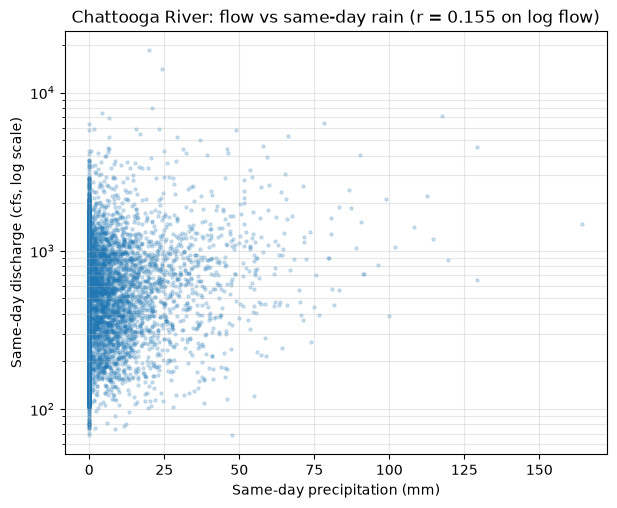

correlation of same-day precip with log discharge: 0.155
days with zero recorded precipitation: 64.5% of the record


In [5]:
one = raw[raw.site == "02177000"].dropna(subset=["discharge_cfs", "prcp"])
r = np.corrcoef(one.prcp, np.log1p(one.discharge_cfs))[0, 1]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(one.prcp, one.discharge_cfs, s=5, alpha=0.2)
ax.set_yscale("log")
ax.set_xlabel("Same-day precipitation (mm)")
ax.set_ylabel("Same-day discharge (cfs, log scale)")
ax.set_title(f"Chattooga River: flow vs same-day rain (r = {r:.3f} on log flow)")
ax.grid(alpha=0.3, which="both")
plt.show()

print(f"correlation of same-day precip with log discharge: {r:.3f}")
print(f"days with zero recorded precipitation: "
      f"{100 * (one.prcp == 0).mean():.1f}% of the record")

# The relationship is weak, and there are two physical reasons.
#
# 1. TIMING. Rain does not become streamflow instantly. Water has to travel over and through
#    the hillslope and down the channel network, which takes hours to days depending on
#    catchment size. Today's peak flow is often the response to rain that fell yesterday or
#    the day before, so pairing same-day values misaligns cause and effect. This is what the
#    lagged features in question 5 exist to fix.
#
# 2. ANTECEDENT WETNESS. The SAME rainfall produces wildly different runoff depending on how
#    saturated the catchment already is. Twenty millimetres onto dry August soil largely
#    infiltrates and produces almost no rise; the same twenty millimetres onto saturated
#    March ground runs straight off and can double the flow. The relationship is not a
#    function of today's rain at all -- it is a function of today's rain AND the state of the
#    catchment, which is why the rolling sums matter.
#
# A third, more mundane point: most days have no rain at all, so the scatter is dominated by
# a vertical stripe at zero precipitation spanning three orders of magnitude in flow. Those
# are recession days, entirely controlled by storage rather than by rainfall.

4. Catchments differ enormously in size, so their discharges are not comparable, the New
River drains 26 times the area of Marsh Creek. Create a column `logQ` holding
$\log(1 + Q/A)$, where $Q$ is discharge in cfs and $A$ is drainage area in square miles.
Plot the distribution of `logQ` for each catchment on shared axes and confirm that they now
overlap.

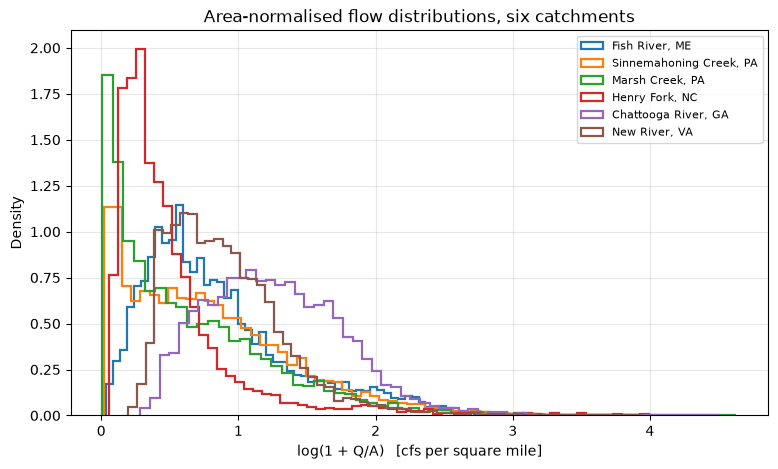

                         count   mean    std
name                                        
Chattooga River, GA       9490  1.272  0.498
Fish River, ME            9490  0.856  0.548
Henry Fork, NC            5435  0.512  0.462
Marsh Creek, PA           9490  0.644  0.587
New River, VA             9490  0.909  0.421
Sinnemahoning Creek, PA   9490  0.784  0.596


In [6]:
raw["logQ"] = np.log1p(raw.discharge_cfs / raw.area_sq_mi)

fig, ax = plt.subplots(figsize=(9, 5))
for site, g in raw.groupby("site"):
    ax.hist(g.logQ.dropna(), bins=60, histtype="step", lw=1.6,
            density=True, label=BASINS[site][3])
ax.set_xlabel("log(1 + Q/A)   [cfs per square mile]")
ax.set_ylabel("Density")
ax.set_title("Area-normalised flow distributions, six catchments")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(raw.groupby("name").logQ.agg(["count", "mean", "std"]).round(3).to_string())

# Normalising by drainage area converts discharge into a runoff RATE per unit area, which is
# a property of the climate and the catchment rather than of its size. The distributions now
# overlap substantially, where the raw discharges would have been separated by more than an
# order of magnitude.
#
# This is what makes a pooled model possible at all. A network trained on raw cfs would spend
# most of its capacity learning which basin it is looking at; trained on the normalised rate,
# it can learn the shared rainfall-runoff behaviour and treat catchment size as one more
# input feature. Residual differences between the curves -- Fish River in Maine is snow-driven
# and behaves quite differently from the southern Appalachian basins -- are real signal that
# the static features in question 7 give the model a chance to use.

## Part 2: Build the features

A network given only today's weather cannot know whether the ground is already saturated.
The catchment's *memory* has to be supplied explicitly, as features describing the recent
past.

5. Working **within each catchment separately** (use `groupby("site")` so that features
never leak across basin boundaries), construct:

- `prcp_lag1` through `prcp_lag10`: precipitation on each of the previous ten days
- `prcp_sum3`, `prcp_sum7`, `prcp_sum14`, `prcp_sum30`, `prcp_sum90`: rolling
  precipitation totals, which act as proxies for how wet the catchment already is
- `tmean_7` and `tmean_30`, rolling mean temperature, a proxy for evaporative demand and
  for whether precipitation is falling as snow
- `doy_sin` and `doy_cos`, the day of year encoded as a pair of sinusoids

In [7]:
df = raw.sort_values(["site", "date"]).reset_index(drop=True)
g = df.groupby("site")

for L in range(1, 11):
    df[f"prcp_lag{L}"] = g["prcp"].shift(L)
for W in (3, 7, 14, 30, 90):
    df[f"prcp_sum{W}"] = g["prcp"].transform(lambda s: s.rolling(W).sum())

df["tmean"] = (df.tmax + df.tmin) / 2
for W in (7, 30):
    df[f"tmean_{W}"] = df.groupby("site")["tmean"].transform(lambda s: s.rolling(W).mean())

df["doy_sin"] = np.sin(2 * np.pi * df.yday / 365)
df["doy_cos"] = np.cos(2 * np.pi * df.yday / 365)

print("engineered:", [c for c in df.columns if c.startswith(("prcp_", "tmean_", "doy_"))])

# Everything is built through groupby("site"), which is essential rather than tidy. A plain
# .shift(1) on the concatenated frame would pull the last day of the Chattooga record into
# the first day of Marsh Creek -- a silent, physically absurd leak across catchment
# boundaries that would not raise any error and would quietly corrupt the first few rows of
# every basin. Whenever a panel dataset is stacked like this, every lag and rolling window
# has to be computed within group.

engineered: ['prcp_lag1', 'prcp_lag2', 'prcp_lag3', 'prcp_lag4', 'prcp_lag5', 'prcp_lag6', 'prcp_lag7', 'prcp_lag8', 'prcp_lag9', 'prcp_lag10', 'prcp_sum3', 'prcp_sum7', 'prcp_sum14', 'prcp_sum30', 'prcp_sum90', 'tmean_7', 'tmean_30', 'doy_sin', 'doy_cos']


6. Also within each catchment, construct `logQ_lag0` through `logQ_lag3`, the
area-normalised log discharge today and on the three previous days. These are the single
most informative features you will build: rivers have long memories.

Then create the **target**, `target`, as `logQ` **three days in the future**. This makes the
task a genuine three-day-ahead forecast, using only information available today.

In [8]:
g = df.groupby("site")
for L in range(0, 4):
    df[f"logQ_lag{L}"] = g["logQ"].shift(L)

LEAD = 3
df["target"] = g["logQ"].shift(-LEAD)

print(f"target: logQ {LEAD} days ahead")
print(df[["name", "date", "logQ", "logQ_lag0", "logQ_lag1", "target"]].head(8).to_string(index=False))

# Note the sign convention. shift(+L) looks BACKWARD in time and is safe -- those values were
# available today. shift(-LEAD) looks FORWARD and is used only for the target, never for a
# feature. Getting that backwards is the classic time-series leakage bug: the model sees the
# future, scores brilliantly, and fails completely in deployment.
#
# logQ_lag0 is today's flow, which IS available at forecast time and is legitimate as a
# feature. It is also, on its own, a very strong predictor -- which is exactly why the
# persistence baseline in question 17 is the one to beat.

target: logQ 3 days ahead
          name       date     logQ  logQ_lag0  logQ_lag1   target
Fish River, ME 1995-01-01 0.376703   0.376703        NaN 0.362406
Fish River, ME 1995-01-02 0.371167   0.371167   0.376703 0.358398
Fish River, ME 1995-01-03 0.366398   0.366398   0.371167 0.356790
Fish River, ME 1995-01-04 0.362406   0.362406   0.366398 0.354373
Fish River, ME 1995-01-05 0.358398   0.358398   0.362406 0.351951
Fish River, ME 1995-01-06 0.356790   0.356790   0.358398 0.348712
Fish River, ME 1995-01-07 0.354373   0.354373   0.356790 0.347089
Fish River, ME 1995-01-08 0.351951   0.351951   0.354373 0.344649


7. Drop rows containing NaN (the lags and rolling windows leave gaps at the start of each
catchment's record, and the target leaves gaps at the end). Assemble the feature matrix `X`
from all the engineered features plus `area_sq_mi`, `lat` and `lon`, and the target vector
`y`. Report the shapes and the number of features.

In [9]:
feature_cols = (["prcp", "tmax", "tmin"]
                + [f"prcp_lag{L}" for L in range(1, 11)]
                + [f"prcp_sum{W}" for W in (3, 7, 14, 30, 90)]
                + ["tmean_7", "tmean_30", "doy_sin", "doy_cos"]
                + [f"logQ_lag{L}" for L in range(0, 4)]
                + ["area_sq_mi", "lat", "lon"])

before = len(df)
model_df = df.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)
print(f"dropped {before - len(model_df):,} rows with NaN; {len(model_df):,} remain")

X = model_df[feature_cols].values
y = model_df["target"].values

print(f"X: {X.shape}   y: {y.shape}")
print(f"{len(feature_cols)} features")
print(f"rows per catchment:")
print(model_df.groupby("name").size().to_string())

dropped 4,582 rows with NaN; 52,358 remain
X: (52358, 29)   y: (52358,)
29 features
rows per catchment:
name
Chattooga River, GA        9398
Fish River, ME             9398
Henry Fork, NC             5368
Marsh Creek, PA            9398
New River, VA              9398
Sinnemahoning Creek, PA    9398


## Part 3: Splitting and scaling

8. Split the data **chronologically**, not randomly: train on everything before 2014,
validate on 2014–2016, and test on 2017 onwards. Report the size of each split.

In a comment, explain why a random split would give a misleadingly good score here. Refer to
what you learned in Assignment 5.

In [10]:
train_mask = model_df.date < "2014-01-01"
val_mask = (model_df.date >= "2014-01-01") & (model_df.date < "2017-01-01")
test_mask = model_df.date >= "2017-01-01"

X_train, y_train = X[train_mask.values], y[train_mask.values]
X_val, y_val = X[val_mask.values], y[val_mask.values]
X_test, y_test = X[test_mask.values], y[test_mask.values]

for name, m in [("train", train_mask), ("validation", val_mask), ("test", test_mask)]:
    d = model_df.loc[m, "date"]
    print(f"{name:<12} {m.sum():>7,} rows   {d.min().date()} to {d.max().date()}   "
          f"({100 * m.mean():.1f}%)")

# WHY NOT A RANDOM SPLIT. Two reasons, both fatal.
#
# 1. Autocorrelation, as in Assignment 5. Daily streamflow is about as autocorrelated as a
#    geophysical series gets -- during a recession, tomorrow's flow is almost a deterministic
#    function of today's. A random split scatters neighbouring days across train and test, so
#    for nearly every test day the model has already seen the days either side of it. It only
#    has to interpolate, and the reported score would be far better than anything achievable
#    in deployment.
#
# 2. The target is a SHIFTED copy of a feature. `target` is logQ three days ahead, and
#    `logQ_lag0` is logQ today. Under a random split, the row three days earlier -- whose
#    features contain the very value that is this row's target -- is very likely in the
#    training set. The answer is sitting in the training data explicitly, not merely
#    approximated by a neighbour. This is direct leakage, and it is created by the random
#    split itself.
#
# Splitting on time removes both, and it matches how the model would actually be used:
# fitted on the historical record, run forward on days that have not happened yet.

train         37,542 rows   1995-03-31 to 2013-12-31   (71.7%)
validation     6,531 rows   2014-01-01 to 2016-12-30   (12.5%)
test           8,285 rows   2017-01-01 to 2020-12-27   (15.8%)


9. Scale the features with `StandardScaler`. Fit the scaler on the **training set only**,
then transform all three sets with it. Explain in a comment what would leak if you fitted it
on everything.

In [11]:
scaler = StandardScaler().fit(X_train)          # fitted on TRAINING rows only

X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"training features: mean {X_train_s.mean():.2e}, sd {X_train_s.std():.4f}")
print(f"test features:     mean {X_test_s.mean():+.4f}, sd {X_test_s.std():.4f}")

# The test set does NOT come out with mean 0 and sd 1, and that is the correct behaviour: it
# is being expressed in the training period's units. Any drift between the periods -- a
# wetter decade, a warming trend -- shows up as a shifted mean here, which is information you
# want to see rather than standardize away.
#
# WHAT WOULD LEAK if the scaler were fitted on everything: the mean and standard deviation of
# each feature would be computed partly from 2017-2020 data, so every training row would have
# been transformed using summary statistics of the future. In deployment that is impossible --
# the future has not happened, so those statistics do not exist. The score would be
# optimistic and, worse, unreproducible.

training features: mean -2.36e-13, sd 1.0000
test features:     mean +0.1120, sd 1.0912


## Part 4: Train a neural network

10. Using `tensorflow`, build a fully connected network that takes the feature matrix as
input and has three hidden `Dense` layers of 128, 64 and 32 units with `ReLU` activation,
followed by a final `Dense` layer with a single output and no activation.

In [12]:
model = Sequential([
    Input(shape=(X_train_s.shape[1],)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1),                       # linear output: logQ is unbounded and can be negative
])
print("built with input dimension", X_train_s.shape[1])

built with input dimension 29


11. Print the model summary. How many trainable parameters does it have?

In [13]:
model.summary()
print()
print(f"total trainable parameters: {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 0 (0.00 B)


total trainable parameters: 14,209


12. Compile the model with MSE loss and the `Adam` optimizer, including root mean squared error as a metric.

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
)
print("compiled: loss = MSE, optimizer = Adam, metric = RMSE")

compiled: loss = MSE, optimizer = Adam, metric = RMSE


13. Train the model for up to 200 epochs using the validation set, with an `EarlyStopping`
callback (`patience=20`, `restore_best_weights=True`). Report the epoch it stopped at.

In [15]:
early = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True,
                                      monitor="val_loss")

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200,
    batch_size=128,
    callbacks=[early],
    verbose=2,
)

print()
print(f"stopped after {len(history.history['loss'])} epochs")
print(f"best epoch (weights restored): {int(np.argmin(history.history['val_loss'])) + 1}")

# EarlyStopping with restore_best_weights is doing real work here. Without it the network
# would keep training past the point where the validation loss bottoms out, and the weights
# left at the end would be worse than the ones it passed through. The validation set is
# 2014-2016 -- chronologically between train and test -- so stopping is decided on data the
# model has not fitted and the test period stays untouched.

Epoch 1/200


294/294 - 1s - 2ms/step - loss: 0.1261 - rmse: 0.3551 - val_loss: 0.0760 - val_rmse: 0.2757


Epoch 2/200


294/294 - 0s - 524us/step - loss: 0.0895 - rmse: 0.2992 - val_loss: 0.0747 - val_rmse: 0.2733


Epoch 3/200


...

Epoch 26/200


294/294 - 0s - 531us/step - loss: 0.0590 - rmse: 0.2429 - val_loss: 0.0768 - val_rmse: 0.2772


Epoch 27/200


294/294 - 0s - 526us/step - loss: 0.0579 - rmse: 0.2406 - val_loss: 0.0763 - val_rmse: 0.2763



stopped after 27 epochs
best epoch (weights restored): 7


14. Plot the training and validation loss against epoch number.

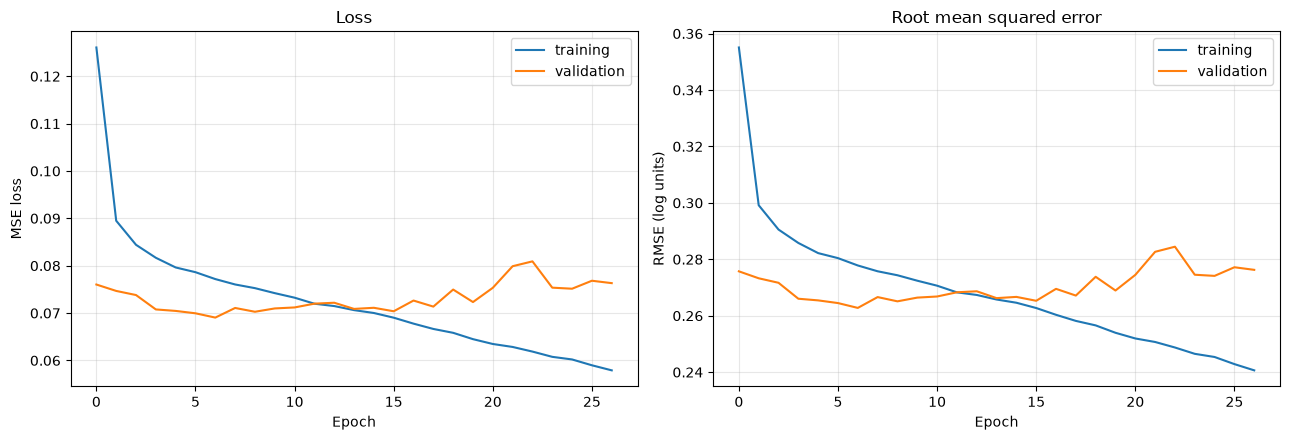

final training loss:   0.05791
best validation loss:  0.06905


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history["loss"], label="training")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["rmse"], label="training")
axes[1].plot(history.history["val_rmse"], label="validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("RMSE (log units)")
axes[1].set_title("Root mean squared error"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"final training loss:   {history.history['loss'][-1]:.5f}")
print(f"best validation loss:  {min(history.history['val_loss']):.5f}")

# The validation loss sits ABOVE the training loss and the gap opens as training proceeds --
# ordinary overfitting, held in check by early stopping. Note that the validation curve here
# is not just a random subsample: it is a different three-year period, so part of the gap is
# genuine year-to-year variability in catchment behaviour rather than memorization.

15. Save the trained model.

In [17]:
model.save("streamflow_model.keras")
print("saved streamflow_model.keras")

reloaded = keras.models.load_model("streamflow_model.keras")
same = np.allclose(model.predict(X_test_s[:200], verbose=0),
                   reloaded.predict(X_test_s[:200], verbose=0))
print("reloaded model reproduces the original predictions:", same)

# Worth saving the scaler alongside the model in real work -- a model that expects
# standardized inputs is useless without the exact means and standard deviations it was
# trained with. joblib.dump(scaler, "scaler.joblib") is the usual way.

saved streamflow_model.keras


reloaded model reproduces the original predictions: True


## Part 5: Evaluate

16. Evaluate the model on the **test** set and report the MSE and RMSE. Then compute the
$R^2$ between predicted and observed `logQ`.

In [18]:
test_loss, test_rmse = model.evaluate(X_test_s, y_test, verbose=0)
y_pred = model.predict(X_test_s, verbose=0).ravel()
r2_nn = r2_score(y_test, y_pred)

print(f"test MSE:  {test_loss:.5f}")
print(f"test RMSE: {test_rmse:.5f}   (log units)")
print(f"test R^2:  {r2_nn:.4f}")

# An RMSE in log units is hard to interpret directly. Because the target is log(1 + Q/A), an
# error of e is roughly a multiplicative factor of exp(e) on the flow rate:
print(f"  an RMSE of {test_rmse:.3f} log units is a typical error of about a factor of "
      f"{np.exp(test_rmse):.2f} on the flow")

test MSE:  0.11180
test RMSE: 0.33436   (log units)
test R^2:  0.7139
  an RMSE of 0.334 log units is a typical error of about a factor of 1.40 on the flow


17. A score means nothing without a baseline. Compare your network against two:

- **Persistence**: predict that the flow in three days equals today's flow
  (`logQ_lag0`). This is what a forecaster with no model at all would say, and on a river
  it is a genuinely strong prediction.
- **Linear regression**: the same features, fitted with `LinearRegression`.

Report $R^2$ for all three on the test set, in one table.

In [19]:
# Baseline 1: persistence -- the flow in three days equals today's flow.
persistence = model_df.loc[test_mask, "logQ_lag0"].values
r2_persist = r2_score(y_test, persistence)

# Baseline 2: linear regression on exactly the same features.
lin = LinearRegression().fit(X_train_s, y_train)
y_lin = lin.predict(X_test_s)
r2_lin = r2_score(y_test, y_lin)

# Baseline 0: predict the training mean.
r2_mean = r2_score(y_test, np.full_like(y_test, y_train.mean()))

rows = [("predict the training mean", r2_mean,
         np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean())))),
        ("persistence (today's flow)", r2_persist,
         np.sqrt(mean_squared_error(y_test, persistence))),
        ("linear regression", r2_lin, np.sqrt(mean_squared_error(y_test, y_lin))),
        ("neural network", r2_nn, np.sqrt(mean_squared_error(y_test, y_pred)))]

print(f"{'model':<32} {'R^2':>9} {'RMSE (log)':>12}")
print("-" * 56)
for name, r2v, rm in rows:
    print(f"{name:<32} {r2v:>9.4f} {rm:>12.4f}")

# The ordering is the point of the question. Persistence is a genuinely strong baseline --
# on a river, "the same as today" is a good three-day forecast most of the time, because most
# days are recession days. Any model that could not beat it would be worthless, and plenty of
# published hydrological models struggle to.
#
# The network beats it, and it also beats a linear regression given exactly the same
# features. That last comparison is the one that justifies the extra machinery: the gain over
# linear is what the nonlinearity actually bought. It is a modest gain, and it should be
# reported as a modest gain rather than dressed up.

model                                  R^2   RMSE (log)
--------------------------------------------------------
predict the training mean          -0.0561       0.6424
persistence (today's flow)          0.5838       0.4033
linear regression                   0.6811       0.3530
neural network                      0.7139       0.3344


18. Make a scatter plot of predicted against observed `logQ` for the test set, with a 1:1 line. Where in the range does the model do worst?

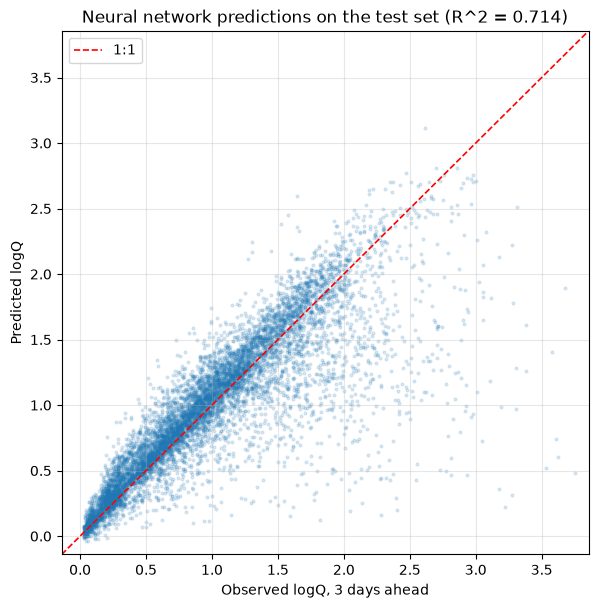

band                    n     RMSE     bias
--------------------------------------------
below median         4143    0.162    0.075
median-90th          3318    0.273   -0.003
90th-99th             755    0.682   -0.406
top 1% (floods)        83    1.630   -1.402


In [20]:
fig, ax = plt.subplots(figsize=(6.8, 6.8))
ax.scatter(y_test, y_pred, s=4, alpha=0.15)
lims = [min(y_test.min(), y_pred.min()) - 0.1, max(y_test.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed logQ, 3 days ahead")
ax.set_ylabel("Predicted logQ")
ax.set_title(f"Neural network predictions on the test set (R^2 = {r2_nn:.3f})")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# Error broken down by flow band -- the question asks where it does worst.
qs = np.quantile(y_test, [0, 0.5, 0.9, 0.99, 1.0])
labels = ["below median", "median-90th", "90th-99th", "top 1% (floods)"]
print(f"{'band':<18} {'n':>6} {'RMSE':>8} {'bias':>8}")
print("-" * 44)
for i, lab in enumerate(labels):
    m = (y_test >= qs[i]) & (y_test <= qs[i + 1])
    if m.sum():
        print(f"{lab:<18} {m.sum():>6} "
              f"{np.sqrt(mean_squared_error(y_test[m], y_pred[m])):>8.3f} "
              f"{(y_pred[m] - y_test[m]).mean():>8.3f}")

# The model is worst at the TOP of the range, and the bias column shows it systematically
# UNDER-predicts the highest flows while slightly over-predicting the lowest. That is
# regression to the mean, and it is the single most important caveat on this model: the
# floods it is least able to predict are the only reason anyone would build it.

19. Plot the observed and predicted hydrograph for one catchment over a single test year, so
that the two curves can be compared day by day. Does the model capture the timing of the
peaks? Does it capture their magnitude?

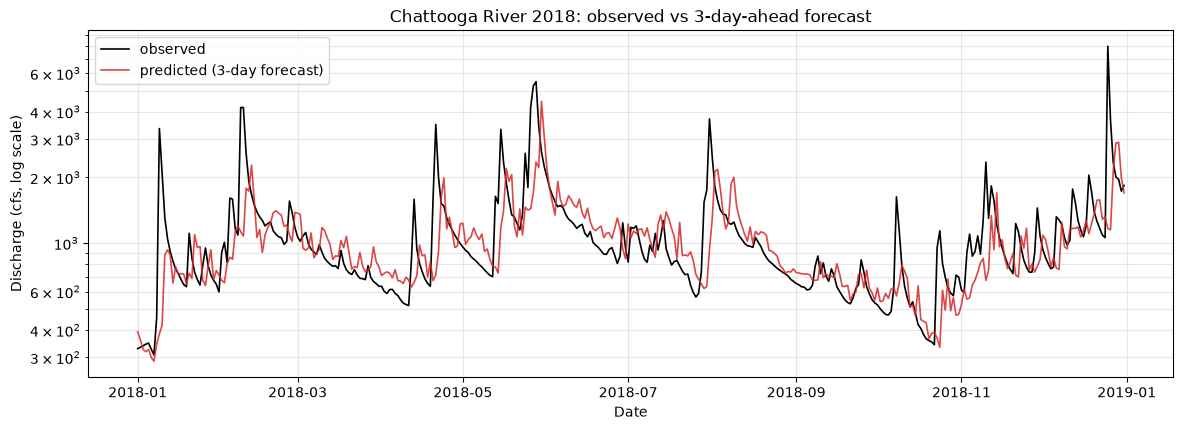

2018, Chattooga: R^2 = 0.3553, RMSE = 0.3280 log units
  on the top 5% of days: bias = -0.862 log units (negative means under-prediction)


In [21]:
sel = model_df.loc[test_mask].copy()
sel["pred"] = y_pred
one = sel[(sel.site == "02177000") & (sel.date.dt.year == 2018)]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(one.date, np.expm1(one.target) * one.area_sq_mi, lw=1.2, color="k",
        label="observed")
ax.plot(one.date, np.expm1(one.pred) * one.area_sq_mi, lw=1.2, color="tab:red",
        alpha=0.85, label="predicted (3-day forecast)")
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (cfs, log scale)")
ax.set_title("Chattooga River 2018: observed vs 3-day-ahead forecast")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

obs = one.target.values
prd = one.pred.values
print(f"2018, Chattooga: R^2 = {r2_score(obs, prd):.4f}, "
      f"RMSE = {np.sqrt(mean_squared_error(obs, prd)):.4f} log units")
peaks = obs >= np.quantile(obs, 0.95)
print(f"  on the top 5% of days: bias = {(prd[peaks] - obs[peaks]).mean():+.3f} log units "
      f"(negative means under-prediction)")

# TIMING is captured well: the predicted curve rises and falls with the observed one, and the
# recessions between events track almost exactly -- unsurprising, since recessions are the
# part of the hydrograph that the antecedent-flow features nail.
#
# MAGNITUDE is where it fails. The peaks are consistently too low, often by a large factor.
# Two things drive this. Predicting three days ahead using only observed rain up to today
# means the rain that will actually cause the peak has not fallen yet. And the squared-error
# loss on a log target rewards being right about the many ordinary days far more than about
# the few extreme ones, so the model hedges towards the middle of the distribution.

## Part 6: Interpretation

20. You trained a single network on six catchments at once, rather than six separate
networks. Explain why pooling helps a neural network here, and what the `area_sq_mi`, `lat`
and `lon` features are doing in a pooled model.

**Pooling works because the six catchments are six samples of the same physical process, and
a neural network has enough capacity to exploit that while a per-basin model does not.**

The rainfall-runoff relationship (infiltration, storage, exponential recession, threshold runoff generation once soil saturates) is the same physics everywhere. What differs between
catchments is the parameters: how fast they drain, how much water they store, how much rain
they get. A model trained on one basin sees roughly 6,500 training days and must learn both
the shared physics *and* that basin's parameters from that one record. A pooled model sees
around 39,000 days and can learn the shared structure from all of them, spending each
catchment's individual data only on what makes it different.

This matters most for the **rare events**, which is the practical argument. Any single
catchment experiences only a handful of genuinely large floods in twenty years, far too few
to learn the extreme end of the response from. Pooling six catchments pools their extremes
too. This is the central finding of the regional deep-learning hydrology literature: a
single network trained across hundreds of basins outperforms individually calibrated
conceptual models *for each individual basin*, precisely because it can borrow strength
across them.

**What `area_sq_mi`, `lat` and `lon` are doing.** They are the model's only way to tell one
catchment from another. Because the target is area-normalised, the network is learning a
shared runoff-generation function, and these static attributes let it *condition* that
function on catchment identity, effectively learning "for a basin of this size at this
location, this much antecedent rain produces this much runoff". Drainage area is the
physically meaningful one: it controls how long water takes to reach the gauge and hence how
sharp the response is. Latitude and longitude are proxies for everything else: climate,
whether the basin is snow-dominated, geology, typical storm type.

That proxy role is also the limitation, and it is the same one as in Assignment 4. Because
location is a lookup key rather than a physical variable, this model cannot be trusted on a
catchment far from the six it was trained on. A real regional model uses *physical* catchment
attributes (mean slope, soil depth, forest fraction, aridity index, snow fraction) so that
a new basin can be described by its properties rather than located by its coordinates. That
is what makes such models transferable to ungauged catchments, which is the problem the field
actually cares about.

21. Compare the error on the highest flows against the error on typical flows. Floods are
the reason anyone builds this model, and they are the hardest part of the range to get
right. Give two reasons why, and suggest one concrete change to the training procedure that
would prioritize them.

**Two reasons the highest flows are hardest, and they compound.**

**The loss function does not care about them.** Mean squared error on a log target averages
over every day equally, and the top 1% of days are 1% of the sum. A model can reduce its
loss far more by shaving a little error off thousands of ordinary recession days than by
getting one flood right, so gradient descent allocates capacity accordingly. The result is
the systematic under-prediction visible in questions 18 and 19: the model hedges towards the
conditional mean, which for a right-skewed target is well below the peaks.

**There are almost no examples to learn from.** By definition, extreme floods are rare. Even
pooled across six catchments and twenty-five years, there may be only a few dozen days above
the 99.9th percentile, and each of them is generated by an unusual combination of
circumstances, a saturated catchment meeting an intense storm, or rain falling on snowpack.
The model is being asked to extrapolate to a region of feature space where it has seen very
few points, which is the regime where neural networks are least reliable and where their
errors are least predictable.

A third factor is worth naming: **the physics itself changes at high flows.** Once soil
saturates, runoff generation switches from slow subsurface flow to fast overland flow, a
genuine threshold. Below the threshold the relationship is smooth and easy; above it, it is
steep and abrupt. The training data is overwhelmingly from below the threshold.

**One concrete change to prioritize the peaks:** weight the loss by the observed flow, so
that errors on high-flow days count more. In Keras this is a `sample_weight` array passed to
`fit`, for instance proportional to `exp(logQ)` normalised, or more stably to a rank-based
weight. That directly rewrites the objective the model is optimizing so that flood days are
no longer a rounding error in the loss.

Two alternatives worth mentioning, since each has a different character. An **asymmetric
loss** that penalizes under-prediction more heavily than over-prediction matches the real
cost structure, failing to warn of a flood is far worse than a false alarm. And **predicting
a distribution rather than a point** (a quantile loss, or a network emitting the parameters
of a distribution) lets the model express that the 95th-percentile outcome is much higher
than its best guess, which is what a flood warning system actually needs. The honest caveat
on all three: none of them creates training examples that do not exist, so each buys better
calibration on the extremes rather than genuinely new skill.

22. This model forecasts three days ahead using *observed* precipitation up to today. A real
operational flood forecast needs to run further ahead than that. What would have to change,
and what new source of error would that introduce?

**The observed precipitation would have to be replaced by a weather forecast, and that
substitutes a well-measured input for an uncertain one.**

Every precipitation feature in this model (today's rain, the ten daily lags, the rolling totals) is an *observation* of rain that has already fallen. That is why a three-day lead is
achievable at all: three days is roughly the time it takes water already on the ground to
work through the catchment to the gauge, so the model is largely propagating known inputs
forward rather than predicting the weather. It is exploiting catchment memory, not
meteorological skill.

To forecast further ahead than the catchment's response time, the model needs to know about
rain that has *not yet fallen*. That means feeding it a quantitative precipitation forecast
from a numerical weather prediction model, in the US, typically the National Weather
Service's QPF or an ensemble such as GEFS.

**The new source of error is the rainfall forecast itself, and it becomes dominant.**
Precipitation is among the least skilful fields NWP produces: even at two or three days,
models place storms in the wrong place, mistime them by hours, and misjudge intensity badly,
and skill degrades sharply beyond about a week. So total forecast error becomes the
hydrological model's error *compounded with* the meteorological forecast's error, and beyond
a short lead the second term dominates completely. A hydrological model that is nearly
perfect will still produce a poor ten-day flood forecast if the rainfall forecast is wrong.

Three consequences follow, and they change the design rather than just the accuracy:

- **Training must match deployment.** A model trained on *observed* rain and then run on
  *forecast* rain has a train/test mismatch: the input distribution at deployment is
  blurrier and biased differently from what it learned on. Operational systems retrain or
  fine-tune on archived forecasts (reforecasts) precisely to avoid this.
- **The output should become probabilistic.** With an uncertain input, a single number is
  indefensible. The standard approach is ensemble streamflow prediction: run the
  hydrological model once per NWP ensemble member and report the resulting distribution of
  flows, so the forecast carries the meteorological uncertainty explicitly.
- **A useful diagnostic** is to run the current model with *perfect* future rain, observed
  rain used as if it had been forecast. That gives the ceiling attributable to the
  hydrological model alone, and the gap between it and the real forecast is exactly the cost
  of meteorological uncertainty. Reporting both numbers separates two very different
  problems that a single skill score conflates.